# Xarray + Cloud OISST (One-Month) Basics & Stats

## Submission by Scott Andersen 

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [72]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3?

    ```According to the call to xr.open_mfdataset, we are using h5netcdf engine to read the files from S3, facilitated by Xarray ```

2. Why do we need `storage_options={'anon': True}`?

    ```The backend_kwargs in xr.open_mfdataset are the keyword arguments that are sent to the engine, h5netcdf. anon tells us that the connection is anonymous, and no credentials are needed to make the connection. I attempted to run this with 'anon': False, and received a 'no credentials' error. Basically we need to tell the engine that the data is public so it does not attempt to authenticate.```

3. Inspect dataset attributes: what are the units and long name of `sst`?

   ```Long name of the variable is "Daily sea surface temperature" and the unit is celsius.```


In [73]:
yearmonth = "202109"
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]

ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds


Found 30 files for 202109. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202109/oisst-avhrr-v02r01.20210901.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202109/oisst-avhrr-v02r01.20210902.nc']


<xarray.Dataset> Size: 498MB
Dimensions:  (time: 30, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 240B 2021-09-01T12:00:00 ... 2021-09-30T12...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    anom     (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    id:                         oisst-avhrr-v02r01.20210901.nc
    naming_authority:           gov.noaa.ncei
    ...                         ...
    time_coverage_start:        2021-09-01T00:00:00Z
    time_coverage_end:          2021-09-01T23:59:59Z
    metadata_link:              https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    sensor:                     Thermometer, AVHRR

## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space?

    The time coordinates are named 'time' in the coordinates dict. The long name for time is Center Time of the day. The space coordinates are lat, lon, and zlev, which are basically the x, y and z coordinates on the planet. Their respective long names are latitude, longitude, and sea surface height. Note that zlev appears to always be zero, which makes sense considering this is sea surface temperature data.

2. What is the shape of `sst`?

Inspecting the above dictionary, the 'sst' or sea surface temperature has this shape: (30, 1, 720, 1440), which corresponds to the sea surface temperature given the time, zlev, lat, and lon variables. 

3. How are missing values represented?

    I picked a point on land and checked the SST values and found that they are stored as NaNs in the xarray dataset. 



In [74]:
list(ds.data_vars), list(ds.coords)

(['sst', 'anom', 'err', 'ice'], ['time', 'zlev', 'lat', 'lon'])

In [75]:
# ds.sel(lat=19.0, lon=260, method="nearest")["sst"].values
# To see how missing values are reported I picked a point on land and 
# examined the SST values, finding that they are reported as nans

## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose?

    I wanted to select the el niño region of the pacific which according to this page: https://www.ncei.noaa.gov/access/monitoring/enso/sst, ranges from about 160°E to 90°W, and 5°N to 5°S. So for longitud, given that the unit is degrees east I chose 160 to 270, and for latitude I chose -5 to 5 degrees.

2. How many daily steps are present in this month?

    There appears to be one time step per day, I'm looking at September of 2021, so that's one 30 time steps.





In [76]:
var = "sst"

lon_min, lon_max = 160, 270
lat_min, lat_max =  -5,  5  

def to_0360(lon):
    print(lon)
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    print(out)
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


[160, 270]
[160. 270.]


<xarray.DataArray 'sst' (time: 30, zlev: 1, lat: 40, lon: 440)> Size: 2MB
dask.array<getitem, shape=(30, 1, 40, 440), dtype=float32, chunksize=(1, 1, 40, 440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2021-09-01T12:00:00 ... 2021-09-30T12...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 160B -4.875 -4.625 -4.375 ... 4.375 4.625 4.875
  * lon      (lon) float32 2kB 160.1 160.4 160.6 160.9 ... 269.4 269.6 269.9
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_min:  -300
    valid_max:  4500

In [77]:
to_0360([-100])

[-100]
[260.]


array([260.])

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation?

    According to the executed block, the monthly average SST over the box is 26.31°C, and the standard deviation is 0.0755°C.

2. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies?

    The largest positive anomaly is 0.1390°C, and the largest negative anomaly is -0.1130°C.

3. What day had the warmest/coolest region-mean SST?

    The warmest region-mean SST was September 4th 2021, and the coolest day was September 22nd, 2021.


Month mean SST (°C): 26.305051803588867
Month std SST (°C): 0.07552489638328552


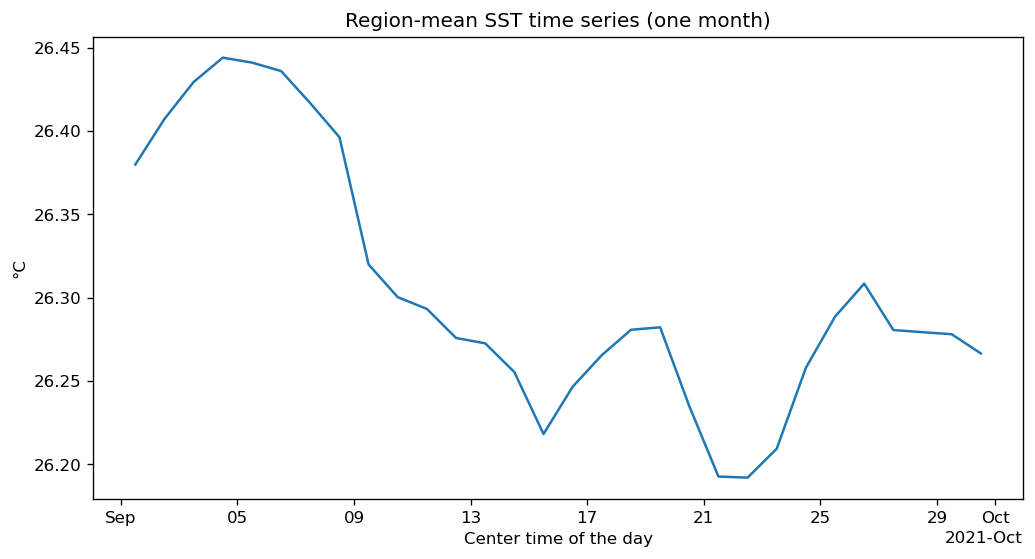

Warmest day: 2021-09-04 26.444074630737305
Coolest day: 2021-09-22 26.192060470581055


/tmp/ipykernel_20375/4235597154.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
/tmp/ipykernel_20375/4235597154.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


In [78]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


Max anomaly (°C): 0.13902272284030914
Min anomaly (°C): -0.11299057304859161


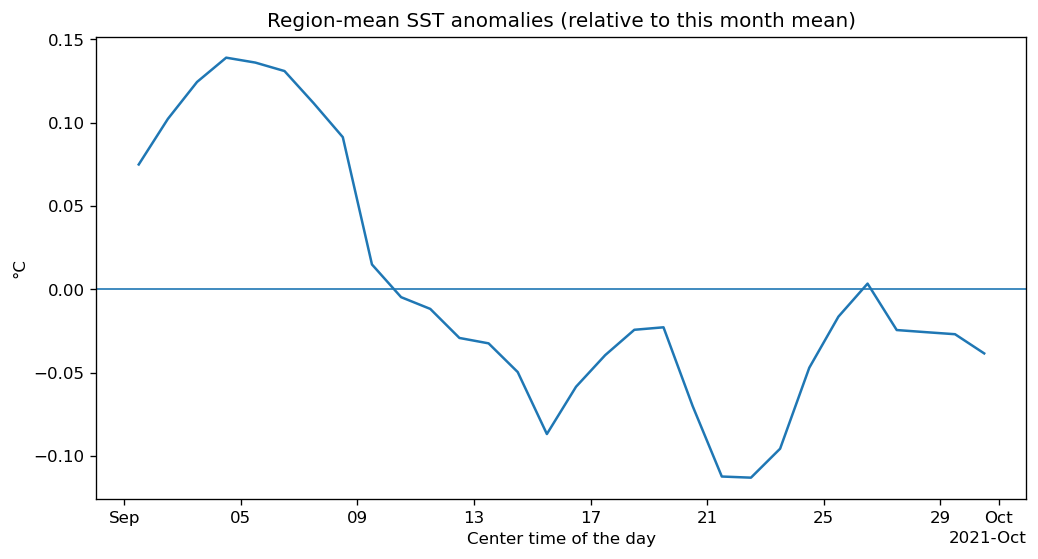

In [79]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice?

    I notice that the monthly mean SST cools dramatically as we move further west, but that is also where we see the most variablity, especially after 240°E, and around the equator.

2. Where is variability strongest?

    Variability is the strongest in the area I just discussed. Around the equator and greater than 240°E. The monthly mean temperature drops substantially, we also see that there is the highest standard deviation in all of the region and the temperature ranges up to 7°C in this region. 


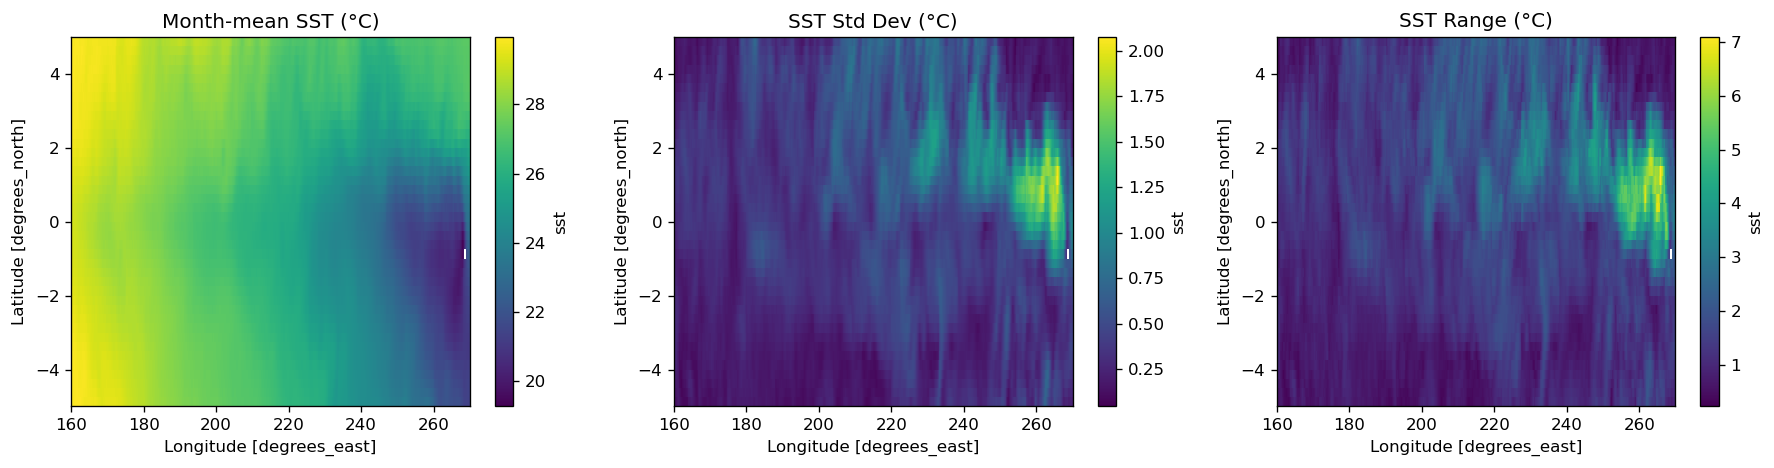

In [80]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

In [83]:
dss.to_netcdf("elnino_region_sst_202109")

In [84]:
# xr.open_dataset("elnino_region_sst_202109")
# just to make sure this saved correctly ;) 